# 米国空港交通：公開データの取得・集計・地理分析

run_id: `v020-exp-27`。言語：日本語。

## 計画
1. インストール済み Kaggle SDK で認証・公開データ検索・ファイル一覧確認・必要ファイル取得を行う。秘密情報は出力しない。
2. 取得日時・owner/dataset slug・ファイル名・SHA-256と項目定義を記録する。Kaggle取得不可の場合のみ指定された旧実験CSVを使用する。
3. 欠損・重複・値域・識別キーを確認し、交通量の単位と対象期間を manifest に明記する。
4. 空港別・都市別・地域別集計、集中度、地理図を選び、感度分析と最大3回の追加分析で解釈を検証する。
5. 全コードセルをJupyter MCPで上から再実行し、visual_audit=Trueの監査とライフサイクルの終端状態を保存する。

交通量の単位は項目確認前に旅客数・便数と決めない。都市と都市圏を区別し、収録空港の合計を米国全体の母集団総量と扱わない。

## 実行方式
コード実行・API取得はJupyter MCPのみ。保存はproject_manager.enqueue_writeを使用する。最初の準備用ノートブックはJupyter MCPが生成したが、本分析ノートブックはensure_notebookで作成した。MCPの初回use_notebookは親ディレクトリ不在、filesystemは設定済み許可ディレクトリ不一致で利用不可だったため、Jupyter MCP内でproject_managerにより保存先を作成した。これはJupytermindの不具合ではない。


In [1]:
from pathlib import Path
import os, sys, io, json, hashlib, re, zipfile, contextlib, inspect
from datetime import datetime, timezone
from dataclasses import asdict
import nbformat
import pandas as pd
import numpy as np
from IPython.display import display
repo = Path('/home/nahisaho/GitHub/jupytermind')
if str(repo / 'src') not in sys.path:
    sys.path.insert(0, str(repo / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(repo / 'benchmark/projects')
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, visualization, insight_engine, notebook_audit
from ai_data_scientist import data_definition, analysis_assumptions, data_quality, sensitivity
handle = pm.resolve_project('kaggle-v020-kaggle-exp-27-airport-traffic')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
run_id = 'v020-exp-27'
lifecycle.register_run(run_id, handle.notebook_path)
language = language_router.detect_language('米国空港交通データの空港・都市ごとの交通量と地理的偏りを分析してください。')
lifecycle_events = []
def phase_event(phase):
    lifecycle_events.append({'at_utc':datetime.now(timezone.utc).isoformat(),'phase':phase,'status':asdict(lifecycle.get_run_status(run_id))})
def execution_start():
    lifecycle.mark_execution_start(run_id)
    phase_event('execution_start')
def execution_end():
    lifecycle.mark_execution_end(run_id)
    phase_event('execution_end')
def write_nb(mutation):
    lifecycle.mark_write_start(run_id)
    phase_event('write_start')
    try:
        return pm.enqueue_write(handle, mutation)
    finally:
        lifecycle.mark_write_end(run_id)
        phase_event('write_end')
def checkpoint():
    if lifecycle.is_cancel_requested(run_id):
        lifecycle.mark_failed(run_id)
        raise RuntimeError('実行がキャンセルされました')
print('language:', language)
print('notebook:', handle.notebook_path)
print('run:', asdict(lifecycle.get_run_status(run_id)))

def persist_cell_execution(marker, actual_output):
    actual_count = get_ipython().execution_count
    def mutate(nb):
        cell = next(c for c in nb.cells if c.cell_type == 'code' and c.source.startswith(marker))
        cell.execution_count = actual_count
        cell.outputs = [nbformat.v4.new_output('display_data', data={'text/plain':actual_output})]
    write_nb(mutate)


language: ja
notebook: /home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-27-airport-traffic/notebooks/kaggle-v020-kaggle-exp-27-airport-traffic.ipynb
run: {'run_id': 'v020-exp-27', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-27-airport-traffic/notebooks/kaggle-v020-kaggle-exp-27-airport-traffic.ipynb', 'reason': None}


In [2]:
# Kaggle SDK による公開データ探索（秘密情報を出力しない）
checkpoint()
execution_start()
search_log = []
kaggle_failure = None
api = None
api_stage = 'authenticate'
try:
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        from kaggle.api.kaggle_api_extended import KaggleApi
        api = KaggleApi()
        api.authenticate()
    api_stage = 'dataset_list'
    for query in ['us airport traffic', '2011 february us airport traffic', 'airport traffic']:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            listed = api.dataset_list(search=query)
        rows = [{'ref': str(d.ref), 'title': str(d.title), 'size_bytes': getattr(d, 'total_bytes', None)} for d in listed]
        search_log.append({'query': query, 'datasets': rows})
        print(json.dumps(search_log[-1], ensure_ascii=False, default=str))
except (Exception, SystemExit) as exc:
    # API例外には認証情報が含まれ得るため、本文を表示せず型と段階だけを記録する。
    kaggle_failure = {'stage': api_stage, 'exception_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None), 'message': '認証または検索失敗。機密漏えい防止のためSDK例外本文は非表示。'}
    print('Kaggle API失敗:', json.dumps(kaggle_failure, ensure_ascii=False))
finally:
    execution_end()
print('search timestamp UTC:', datetime.now(timezone.utc).isoformat())


{"query": "us airport traffic", "datasets": [{"ref": "parulpandey/us-international-air-traffic-data", "title": "U.S. International Air Traffic data(1990-2020)", "size_bytes": 17939017}, {"ref": "eugeniyosetrov/airline-delays", "title": "Airline Delays", "size_bytes": 112515}, {"ref": "jinbonnie/airport-information", "title": "Airport code and geographical information", "size_bytes": 2648096}, {"ref": "syedasimalishah/airports", "title": "Airports", "size_bytes": 349021}, {"ref": "likithagedipudi/ev-charging-station-availability-tracking", "title": "EV Charging Station Availability Tracking", "size_bytes": 23752663}, {"ref": "thedevastator/airport-city-mappings-and-aggregations", "title": "Airport City Mappings and Aggregations", "size_bytes": 257859}, {"ref": "bitsnpieces/covid19-country-data", "title": "COVID-19 Country Data", "size_bytes": 190821}, {"ref": "a7madmostafa/us-flight-delays-2025-bts-on-time-performance", "title": "US Flight Delays 2025 (BTS On-Time Performance)", "size_b

In [3]:
# 候補のファイル一覧とメタデータを確認する
checkpoint()
execution_start()
candidate_refs = ['oparam/us-airport-traffic-data', 'himaxym/us-air-traffic-t100']
file_catalog = {}
metadata_catalog = {}
try:
    if kaggle_failure is None:
        for ref in candidate_refs:
            try:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    result = api.dataset_list_files(ref)
                files = [{'name': f.name, 'size_bytes': getattr(f, 'total_bytes', None)} for f in result.files]
                file_catalog[ref] = files
                print(ref, json.dumps(files, ensure_ascii=False, default=str))
                meta_dir = data_dir / ref.split('/')[0]
                meta_dir.mkdir(exist_ok=True)
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    api.dataset_metadata(ref, path=str(meta_dir))
                meta_path = meta_dir / 'dataset-metadata.json'
                if meta_path.exists():
                    metadata_catalog[ref] = json.loads(meta_path.read_text())
                    public_meta = {k: v for k, v in metadata_catalog[ref].items() if k in ['title', 'id', 'description', 'licenses', 'resources']}
                    print('public metadata:', json.dumps(public_meta, ensure_ascii=False, default=str)[:14000])
            except Exception as exc:
                print('候補確認失敗:', ref, type(exc).__name__, '例外本文は非表示')
finally:
    execution_end()


oparam/us-airport-traffic-data [{"name": "Air_Traffic_Passenger_Statistics.csv", "size_bytes": 5671639}]
public metadata: {}
himaxym/us-air-traffic-t100 [{"name": "airport_passengers_by_year.csv", "size_bytes": 193341}, {"name": "airport_totals_2025.csv", "size_bytes": 12075}, {"name": "carrier_traffic_by_year.csv", "size_bytes": 147492}, {"name": "top_routes_2025.csv", "size_bytes": 589}, {"name": "us_air_traffic_by_year.csv", "size_bytes": 2302}]
public metadata: {}


In [4]:
# 全国の空港別データを優先し、都市・位置情報候補も調べる
checkpoint()
execution_start()
provenance = []
loaded = {}
selected_slug = 'himaxym/us-air-traffic-t100'
try:
    for ref, meta in metadata_catalog.items():
        print('metadata keys:', ref, list(meta))
        for k, v in meta.items():
            if any(term in k.lower() for term in ['description', 'title', 'license', 'resource']):
                print(k, str(v)[:16000])
    for filename in ['airport_totals_2025.csv', 'airport_passengers_by_year.csv', 'us_air_traffic_by_year.csv']:
        target = data_dir / 't100'
        target.mkdir(exist_ok=True)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file(selected_slug, filename, path=str(target), force=True, quiet=True)
        path = target / filename
        if not path.exists() and Path(str(path) + '.zip').exists():
            with zipfile.ZipFile(str(path) + '.zip') as archive:
                path.write_bytes(archive.read(filename))
        payload = path.read_bytes()
        record = {'owner_dataset_slug': selected_slug, 'filename': filename, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(payload).hexdigest(), 'bytes': len(payload), 'url': 'https://www.kaggle.com/datasets/' + selected_slug, 'fallback': False}
        provenance.append(record)
        loaded[filename] = ingestion.ingest(ingestion.SourceSpec(kind='csv', location=str(path)), row_limit=100000).dataframe
        print(json.dumps(record, ensure_ascii=False))
        print('shape:', loaded[filename].shape, 'columns:', list(loaded[filename]))
        display(loaded[filename].head(8))
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        geo_files_response = api.dataset_list_files('jinbonnie/airport-information')
    print('geo candidate files:', [{'name': f.name, 'bytes': getattr(f, 'total_bytes', None)} for f in geo_files_response.files])
except Exception as exc:
    kaggle_failure = {'stage': 'dataset_download_file or ingestion', 'exception_type': type(exc).__name__, 'message': '取得・読み込み失敗。例外本文は非表示。'}
    print(json.dumps(kaggle_failure, ensure_ascii=False))
    lifecycle.mark_failed(run_id)
    raise RuntimeError('Kaggleデータの取得または読み込みに失敗（機密情報を含み得る原例外は非表示）') from None
finally:
    execution_end()


metadata keys: oparam/us-airport-traffic-data ['info']
metadata keys: himaxym/us-air-traffic-t100 ['info']
{"owner_dataset_slug": "himaxym/us-air-traffic-t100", "filename": "airport_totals_2025.csv", "retrieved_at_utc": "2026-10-01T20:58:05.361002+00:00", "sha256": "4299a70801d71656428ce0f5f24b6581bd27eb9eb461e25d25055e0560cbf58d", "bytes": 12075, "url": "https://www.kaggle.com/datasets/himaxym/us-air-traffic-t100", "fallback": false}
shape: (653, 4) columns: ['iata', 'passengers_2025', 'flights_2025', 'rank_2025']
{"owner_dataset_slug": "himaxym/us-air-traffic-t100", "filename": "airport_passengers_by_year.csv", "retrieved_at_utc": "2026-10-01T20:58:07.483404+00:00", "sha256": "08c6eb93464437b35f180aded0d2020604794ffd6fdde2212deb6a636d9cafce", "bytes": 193341, "url": "https://www.kaggle.com/datasets/himaxym/us-air-traffic-t100", "fallback": false}
shape: (19332, 3) columns: ['iata', 'year', 'passengers']
{"owner_dataset_slug": "himaxym/us-air-traffic-t100", "filename": "us_air_traffic

,iata,passengers_2025,flights_2025,rank_2025
0,ATL,51408843,385652,1
1,DFW,41338411,353347,2
2,ORD,40818844,403903,3
3,DEN,40087200,339035,4
4,LAX,36361906,256000,5
5,JFK,30640597,210381,6
6,MCO,27958532,190891,7
7,LAS,26466190,198670,8


,iata,year,passengers
0,1G4,2012,NaN
1,1G4,2013,NaN
2,1G4,2014,NaN
3,1G4,2015,NaN
4,1G4,2016,NaN
5,1G4,2017,NaN
6,1G4,2022,NaN
7,1G4,2023,NaN


,year,passengers,passengers_domestic,passengers_international,flights,seats,load_factor
0,1990,529914608,448226421,81688187,6817861,929464889,0.570
1,1991,513725305,434184608,79540697,6688037,908632466,0.565
2,1992,540881241,453477283,87403958,6929618,944851065,0.572
3,1993,554950912,463623710,91327202,7093305,951171734,0.583
4,1994,600313070,504489758,95823312,7398144,978554783,0.613
5,1995,621147503,518831581,102315922,7951779,1007559278,0.616
6,1996,657501638,547556381,109945257,8111104,1025158276,0.641
7,1997,681258612,563628422,117630190,8083991,1044906785,0.652


In [5]:
# 地理参照CSVの取得と出典定義の確認
checkpoint()
execution_start()
try:
    for ref, meta in metadata_catalog.items():
        info = meta.get('info', {})
        print('PUBLIC DATASET METADATA', ref)
        print(json.dumps({k:v for k,v in info.items() if any(term in k.lower() for term in ['description', 'title', 'license', 'resource', 'subtitle'])}, ensure_ascii=False, default=str)[:24000])
    geo_slug = 'jinbonnie/airport-information'
    geo_name = 'airport_code.csv'
    geo_dir = data_dir / 'geography'
    geo_dir.mkdir(exist_ok=True)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_download_file(geo_slug, geo_name, path=str(geo_dir), force=True, quiet=True)
    geo_path = geo_dir / geo_name
    if not geo_path.exists() and Path(str(geo_path) + '.zip').exists():
        with zipfile.ZipFile(str(geo_path) + '.zip') as archive:
            geo_path.write_bytes(archive.read(geo_name))
    payload = geo_path.read_bytes()
    provenance.append({'owner_dataset_slug': geo_slug, 'filename': geo_name, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(payload).hexdigest(), 'bytes': len(payload), 'fallback': False, 'url': 'https://www.kaggle.com/datasets/' + geo_slug})
    geo_raw = ingestion.ingest(ingestion.SourceSpec('csv', str(geo_path)), row_limit=100000).dataframe
    print('PROVENANCE', json.dumps(provenance[-1], ensure_ascii=False))
    print('geography shape:', geo_raw.shape, 'columns:', list(geo_raw))
    display(geo_raw.head(4))
    print('annual last rows:')
    display(loaded['us_air_traffic_by_year.csv'].tail(10))
finally:
    execution_end()


PUBLIC DATASET METADATA oparam/us-airport-traffic-data
{"title": "US Airport traffic data", "subtitle": "", "description": "", "licenses": [{"name": "unknown"}]}
PUBLIC DATASET METADATA himaxym/us-air-traffic-t100
{"title": "US Air Traffic by Airport and Airline (T-100)", "subtitle": "Passengers, flights, seats and load factor: US national, airports, carriers", "description": "# US Air Traffic, 1990-2026 (BTS T-100)\n\nThe **whole US air travel market in tidy CSVs**: national passengers/flights/seats/load-factor since 1990, per-airport passenger series for 653 airports, and per-carrier series for 167 airlines - aggregated from the BTS T-100 segment data (18M raw rows).\n\n**Headline: 2024 set the all-time record - 1.115 billion passengers.** 2020 bottomed at 405M (-62%).\n\n## Files\n| File | Rows | What it contains |\n|---|---|---|\n| `us_air_traffic_by_year.csv` | 37 | National totals: passengers (dom/intl), flights, seats, load factor |\n| `airport_passengers_by_year.csv` | 19,332 |

,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,gps_code,local_code
0,6523,00A,heliport,Total Rf Heliport,40.070801,-74.933601,11.0,NaN,US,US-PA,Bensalem,no,00A,00A
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,00AA,00AA
2,6524,00AK,small_airport,Lowell Field,59.949200,-151.695999,450.0,NaN,US,US-AK,Anchor Point,no,00AK,00AK
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,00AL,00AL


,year,passengers,passengers_domestic,passengers_international,flights,seats,load_factor
27,2017,976410046,751444973,224965073,9741673,1201293575,0.813
28,2018,1023730870,786887511,236843359,9941588,1253297326,0.817
29,2019,1061982130,820095081,241887049,10185187,1289923099,0.823
30,2020,405082767,341450671,63632096,5804682,707650608,0.572
31,2021,707800223,613129458,94670765,7654349,960440706,0.737
32,2022,947187322,759851458,187335864,8776979,1171383804,0.809
33,2023,1063452848,828907229,234545619,9393767,1311682341,0.811
34,2024,1114768527,859288285,255480242,9848340,1371688261,0.813
35,2025,1104406537,848359369,256047168,10065776,1390151288,0.794
36,2026,341351153,263655153,77696000,3188778,440115298,0.776


## 採用データと対象期間
`himaxym/us-air-traffic-t100` を採用。`oparam/us-airport-traffic-data` は説明・単位・全国収録範囲が確認できず不採用。取得はKaggle API成功につき指定Plotly CSVへのフォールバックなし。交通データの帰属：FlightFinder (himaxym.com)、原出典BTS T-100、掲載ライセンスCC BY 4.0。

主分析は掲載者が「last full year」と説明する2025年。全国年次系列は1990–2026年で、2026年は約5月までの部分年とされるため前年差・年次順位の比較から除外する。月別行がないため2025年の12か月完全収録は独立に検証できず、季節性・月次ピーク・2026年の通年推計は行わない。2025年旅客列は掲載者が乗降合計と説明するが、実値との整合性を追加確認する。ユニーク旅行者数や都市居住者の需要ではない。

地理参照 `jinbonnie/airport-information` は別のKaggle公開CSVであり、交通量の独立検証データではない。`iata`列が地理CSVには無く、米国local_codeによる結合は仮定として記録し、結合率・不一致・上位空港名称を確認する。municipalityは空港所在地の自治体名であり、都市圏ではない。


In [6]:
# 項目・欠損・意味的異常検査と初回集計
checkpoint()
execution_start()
try:
    airports_raw = loaded['airport_totals_2025.csv'].copy()
    clean_report = cleaning.clean_dataset(airports_raw, operation='drop_duplicates')
    airports = clean_report.dataframe.copy()
    annual = loaded['us_air_traffic_by_year.csv'].copy()
    history = loaded['airport_passengers_by_year.csv'].copy()
    print('CLEANING', {'rows_before': clean_report.rows_before, 'rows_after': clean_report.rows_after, 'rows_removed': clean_report.rows_removed, 'columns_affected': clean_report.columns_affected})
    report = eda.explore(airports)
    print('EDA airport', json.dumps(asdict(report), ensure_ascii=False, default=str))
    print('history missing:', history.isna().sum().to_dict(), 'duplicate keys:', int(history.duplicated(['iata', 'year']).sum()))
    airport_anomalies = data_quality.detect_anomalies(airports, schema={'iata': {'not_null': True, 'unique': True}, 'passengers_2025': {'not_null': True, 'min': 0}, 'flights_2025': {'not_null': True, 'min': 0}, 'rank_2025': {'min': 1, 'max': len(airports)}})
    annual_anomalies = data_quality.detect_anomalies(annual, schema={'year': {'unique': True, 'min': 1990, 'max': 2026}, 'passengers': {'not_null': True, 'min': 0}, 'load_factor': {'min': 0, 'max': 1}})
    print('SEMANTIC ANOMALIES', [asdict(a) for a in airport_anomalies + annual_anomalies])
    print('domestic+international=total:', bool((annual.passengers_domestic + annual.passengers_international == annual.passengers).all()))
    print('load factor rounding max error:', float((annual.passengers / annual.seats - annual.load_factor).abs().max()))
    geo_us = geo_raw.loc[geo_raw.iso_country.eq('US') & geo_raw.local_code.notna()].copy()
    geo_duplicates = geo_us.loc[geo_us.local_code.duplicated(keep=False)].sort_values('local_code')
    print('ambiguous US local codes:', len(geo_duplicates), geo_duplicates.local_code.unique().tolist()[:30])
    geo_unique = geo_us.loc[~geo_us.local_code.duplicated(keep=False)].copy()
    joined = airports.merge(geo_unique[['local_code', 'name', 'municipality', 'iso_country', 'iso_region', 'latitude_deg', 'longitude_deg', 'type']], left_on='iata', right_on='local_code', how='left', validate='one_to_one', indicator=True)
    total = int(airports.passengers_2025.sum())
    joined['share_pct'] = joined.passengers_2025 / total * 100
    print('BASELINE total airport-column passengers:', total)
    print('BASELINE positive airports:', int(airports.passengers_2025.gt(0).sum()))
    print('BASELINE airport top10 share pct:', f'{airports.nlargest(10, "passengers_2025").passengers_2025.sum()/total*100:.6f}')
    print('BASELINE match count:', int(joined._merge.eq('both').sum()), 'passenger coverage pct:', f'{joined.loc[joined._merge.eq("both"), "passengers_2025"].sum()/total*100:.6f}')
    print('Unmatched airports:')
    display(joined.loc[joined._merge.ne('both'), ['iata', 'passengers_2025']].sort_values('passengers_2025', ascending=False).head(25))
    print('Airport top20:')
    display(joined.sort_values('passengers_2025', ascending=False).head(20)[['iata','name','municipality','iso_region','passengers_2025','flights_2025','share_pct']])
    cities = joined.loc[joined.municipality.notna()].groupby(['iso_region','municipality'], as_index=False).agg(passengers=('passengers_2025','sum'), flights=('flights_2025','sum'), airport_count=('iata','count')).sort_values('passengers', ascending=False)
    print('Municipality top15:')
    display(cities.head(15))
    print('national 2025 total:', int(annual.loc[annual.year.eq(2025), 'passengers'].iloc[0]), 'airport/national ratio:', total/annual.loc[annual.year.eq(2025), 'passengers'].iloc[0])
finally:
    execution_end()


CLEANING {'rows_before': 653, 'rows_after': 653, 'rows_removed': 0, 'columns_affected': ['iata', 'passengers_2025', 'flights_2025', 'rank_2025']}
EDA airport {"describe": {"passengers_2025": {"count": 653.0, "mean": 1489289.3093415007, "std": 5329531.579206487, "min": 1.0, "25%": 3206.0, "50%": 25562.0, "75%": 351056.0, "max": 51408843.0}, "flights_2025": {"count": 653.0, "mean": 13926.543644716692, "std": 44012.89369755085, "min": 1.0, "25%": 623.0, "50%": 1162.0, "75%": 5996.0, "max": 403903.0}, "rank_2025": {"count": 653.0, "mean": 327.0, "std": 188.64914524057616, "min": 1.0, "25%": 164.0, "50%": 327.0, "75%": 490.0, "max": 653.0}}, "dtypes": {"iata": "str", "passengers_2025": "int64", "flights_2025": "int64", "rank_2025": "int64"}, "non_null_counts": {"iata": 653, "passengers_2025": 653, "flights_2025": 653, "rank_2025": 653}, "missing_summary": {"iata": {"missing_count": 0, "missing_ratio": 0.0}, "passengers_2025": {"missing_count": 0, "missing_ratio": 0.0}, "flights_2025": {"mis

,iata,passengers_2025
37,SJU,6662792
104,AZA,1017101
108,GUM,890399
112,STT,805152
135,FCA,560624
169,BQN,335148
180,STX,267383
195,USA,191893
198,SPN,170680
207,SCE,147976


,iata,name,municipality,iso_region,passengers_2025,flights_2025,share_pct
0,ATL,Hartsfield Jackson Atlanta International Airport,Atlanta,US-GA,51408843,385652,5.286224
1,DFW,Dallas Fort Worth International Airport,Dallas-Fort Worth,US-TX,41338411,353347,4.250710
2,ORD,Chicago O'Hare International Airport,Chicago,US-IL,40818844,403903,4.197285
3,DEN,Denver International Airport,Denver,US-CO,40087200,339035,4.122052
4,LAX,Los Angeles International Airport,Los Angeles,US-CA,36361906,256000,3.738991
5,JFK,John F Kennedy International Airport,New York,US-NY,30640597,210381,3.150685
6,MCO,Orlando International Airport,Orlando,US-FL,27958532,190891,2.874896
7,LAS,McCarran International Airport,Las Vegas,US-NV,26466190,198670,2.721443
8,SFO,San Francisco International Airport,San Francisco,US-CA,26398412,187069,2.714473
9,CLT,Charlotte Douglas International Airport,Charlotte,US-NC,25891580,258788,2.662357


,iso_region,municipality,passengers,flights,airport_count
227,US-GA,Atlanta,51408843,385652,1
262,US-IL,Chicago,50235168,480522,2
420,US-NY,New York,46917650,382236,2
486,US-TX,Dallas-Fort Worth,41338411,353347,1
188,US-CO,Denver,40087200,339035,1
163,US-CA,Los Angeles,36361906,256000,1
491,US-TX,Houston,30127520,272357,2
214,US-FL,Orlando,29505062,201370,2
411,US-NV,Las Vegas,26466190,198670,1
175,US-CA,San Francisco,26398412,187069,1


## 初回分析の読み直しと反復依頼履歴

### 反復1：定義と時系列の整合性（追加依頼原文）
「空港別旅客数の説明が乗降合計となっている一方、空港別合計と全国合計が一致せず、空港別年次CSVの旅客数が全欠損です。各ファイルの合計、欠損、便数と旅客数の順位、旅客数を一律2倍した場合の集中度を確認し、解釈できる範囲とできない範囲を明確にしてください。」

選定理由：単位の誤読は絶対交通量を倍違いにし、全欠損の年次系列では空港別成長率を分析できない。結果・証拠・残る限界は次のセルに記録する。


In [7]:
# 反復1：ファイル整合性、統計の意味、定義manifest
checkpoint()
execution_start()
try:
    annual_2025 = annual.loc[annual.year.eq(2025)].iloc[0]
    coherence = {
        'airport_passenger_sum': total,
        'national_passenger_sum': int(annual_2025.passengers),
        'airport_to_national_ratio': total / annual_2025.passengers,
        'airport_flight_sum': int(airports.flights_2025.sum()),
        'national_flight_sum': int(annual_2025.flights),
        'history_rows': len(history),
        'history_missing_passengers': int(history.passengers.isna().sum()),
        'history_missing_fraction': float(history.passengers.isna().mean()),
        'top_passenger_airport': airports.loc[airports.passengers_2025.idxmax(), 'iata'],
        'top_flight_airport': airports.loc[airports.flights_2025.idxmax(), 'iata'],
    }
    print('ITERATION1', json.dumps(coherence, ensure_ascii=False))
    display({'text/plain':'ITERATION1 ' + json.dumps(coherence, ensure_ascii=False)}, raw=True)
    unit_plan = sensitivity.SensitivityPlan(parameter_grid={'multiplier': [1, 2]}, max_runs=2)
    unit_sensitivity = sensitivity.run_sensitivity(unit_plan, lambda multiplier: (airports.passengers_2025 * multiplier).nlargest(10).sum() / (airports.passengers_2025 * multiplier).sum(), stability_tolerance=0.001)
    print('UNIT_SENSITIVITY', json.dumps(asdict(unit_sensitivity), default=str))
    fv = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={'provider': fv('Kaggle / FlightFinder (himaxym.com)', 'verified', provenance[0]['url']), 'original_source': fv('BTS T-100（掲載者の説明）', 'verified', provenance[0]['url']), 'license': fv('CC BY 4.0', 'verified', provenance[0]['url']), 'geography_source': fv('Kaggle jinbonnie/airport-information', 'verified', provenance[-1]['url'])},
        dataset_scope={'main_year': fv(2025, 'verified', 'file name + metadata'), 'full_year_completeness': fv('掲載者は最終完全年と説明。月別完全性は確認不可', 'inferred', 'Kaggle metadata'), 'partial_year_excluded': fv(2026, 'verified', 'metadata: through approximately May'), 'population_coverage': fv('BTS報告対象便の全国範囲と説明。ただし空港計と全国計は不一致', 'unknown', 'ITERATION1 coherence'), 'geo_reference_date': fv(None, 'unknown', 'Kaggle location CSV has no reference date')},
        variables={
            'iata': {'definition': fv('空港識別コード。local_codeとの一致は全空港で保証されない', 'inferred', 'join diagnostics'), 'unit': fv('code', 'verified', 'CSV header')},
            'passengers_2025': {'unit': fv('旅客カウント列（ユニーク人数ではない）', 'inferred', 'CSV+metadata'), 'published_definition': fv('enplaned + deplaned on touching segments と掲載者は説明', 'verified', 'Kaggle metadata'), 'actual_direction': fv('乗降合計か出発のみか独立確認できない', 'unknown', 'airport/national mismatch'), 'missingness': fv('2025年列に欠損なし', 'verified', 'EDA')},
            'flights_2025': {'unit': fv('運航便カウント', 'inferred', 'CSV+subtitle'), 'actual_direction': fv('出発・到着・両方のどれかは不明', 'unknown', 'metadata does not define direction')},
            'rank_2025': {'definition': fv('旅客列の降順順位', 'inferred', 'ordering test')},
            'municipality': {'definition': fv('地理CSVの自治体文字列。都市圏ではない', 'inferred', 'CSV values'), 'historical_validity_2025': fv(None, 'unknown', 'reference date unavailable')},
            'latitude_deg': {'unit': fv('緯度、度', 'inferred', 'header and range')},
            'longitude_deg': {'unit': fv('経度、度', 'inferred', 'header and range')},
            'history.passengers': {'usability': fv('全19332行欠損のため分析対象外', 'verified', 'ITERATION1')},
        }, transformations=('完全一致行のみ重複除去（除去0）', 'US local_codeの一意候補のみ結合', 'municipality+iso_regionを都市キーにする', '部分年2026を通年比較から除外'))
    print('DATA_DEFINITION_MANIFEST', json.dumps(asdict(definition_manifest), ensure_ascii=False, default=str))
    print('UNRESOLVED_FIELDS', [(k, asdict(v)) for k,v in definition_manifest.unresolved_fields()])
    inferred_fields = [(f'variables.{var}.{key}', asdict(value)) for var, fields in definition_manifest.variables.items() for key,value in fields.items() if value.status == 'inferred']
    print('INFERRED_CAVEATS', inferred_fields)
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'year': 2025, 'unit': 'recorded passenger counts', 'target': 'descriptive airport and city concentration'},
        causal_scope='descriptive',
        assumptions=(
            analysis_assumptions.Assumption('A1', '空港旅客列は全空港で比較可能なカウント', 'assumed', impact_if_false='相対順位・構成比の解釈が変わる', conclusion_critical=True),
            analysis_assumptions.Assumption('A2', '2025年は完全通年', 'assumed', impact_if_false='年間交通量として解釈できない', conclusion_critical=True),
            analysis_assumptions.Assumption('A3', 'local_codeはiataの十分な代替', 'assumed', impact_if_false='地理結合・都市集計が変わる', conclusion_critical=True),
            analysis_assumptions.Assumption('A4', 'municipalityは都市圏そのもの', 'rejected', impact_if_false='都市圏ランキングを名乗らず自治体文字列集計に限定'),
            analysis_assumptions.Assumption('A5', '空港別年次旅客数による成長率分析が可能', 'rejected', impact_if_false='全欠損のため分析しない'),
        ))
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
    print('ASSUMPTION_MANIFEST', json.dumps(asdict(assumption_manifest), ensure_ascii=False, default=str))
    print('ASSUMPTION_FINDINGS', [asdict(f) for f in assumption_findings])
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        alternative_geo_files = api.dataset_list_files('syedasimalishah/airports')
    print('alternative geo files:', [f.name for f in alternative_geo_files.files])
finally:
    execution_end()


ITERATION1 {"airport_passenger_sum": 972505919, "national_passenger_sum": 1104406537, "airport_to_national_ratio": 0.880568781892315, "airport_flight_sum": 9094033, "national_flight_sum": 10065776, "history_rows": 19332, "history_missing_passengers": 19332, "history_missing_fraction": 1.0, "top_passenger_airport": "ATL", "top_flight_airport": "ORD"}
UNIT_SENSITIVITY {"results": [{"specification": {"multiplier": 1}, "value": 0.3571911576200905}, {"specification": {"multiplier": 2}, "value": 0.3571911576200905}], "baseline_value": 0.3571911576200905, "stable": true, "max_relative_deviation": 0.0}
DATA_DEFINITION_MANIFEST {"source": {"provider": {"value": "Kaggle / FlightFinder (himaxym.com)", "status": "verified", "source": "https://www.kaggle.com/datasets/himaxym/us-air-traffic-t100"}, "original_source": {"value": "BTS T-100（掲載者の説明）", "status": "verified", "source": "https://www.kaggle.com/datasets/himaxym/us-air-traffic-t100"}, "license": {"value": "CC BY 4.0", "status": "verified", "s

ITERATION1 {"airport_passenger_sum": 972505919, "national_passenger_sum": 1104406537, "airport_to_national_ratio": 0.880568781892315, "airport_flight_sum": 9094033, "national_flight_sum": 10065776, "history_rows": 19332, "history_missing_passengers": 19332, "history_missing_fraction": 1.0, "top_passenger_airport": "ATL", "top_flight_airport": "ORD"}

### 反復1の判断
空港列合計と全国合計は一致せず、空港別年次列は全欠損である。旅客と便数で首位が違うため、交通量は旅客列・便数列を別々に評価する。単位一律2倍による集中度の感度は0だが、これは実際の方向別定義を検証したことにはならない。絶対値は「CSVの記録旅客カウント」と表示し、乗降合計・出発旅客・全国シェアへの言い換えはしない。残る限界：空港別成長率不可、掲載者の集計コード・月次原票未確認。A1（空港間定義の比較可能性）、A2（完全年）、A3（コード結合）の警告を保持する。

### 反復2：結合漏れと都市定義（追加依頼原文）
「地理CSVにIATA列がないことによる結合漏れや米国領域の除外が、都市・地域ランキングを変えるか確認してください。別のKaggle空港一覧を取得してIATAで結合し、座標・名称の一致、未結合交通量、自治体と主要都市圏の集約差を検証してください。」

選定理由：初回にはlocal_codeとIATAが違うAZA等と米国領域が未結合だった。New YorkとNewark、Dallas-Fort WorthとDallasを別扱いすると都市順位が変わる可能性がある。都市圏は公式境界でなく、明示的な主要空港グループの感度比較に限定する。


In [8]:
# 反復2：別Kaggle地理参照の取得
checkpoint()
execution_start()
try:
    ref2_slug = 'syedasimalishah/airports'
    ref2_name = 'airports_w_headers.csv'
    ref2_dir = data_dir / 'geography_iata'
    ref2_dir.mkdir(exist_ok=True)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_download_file(ref2_slug, ref2_name, path=str(ref2_dir), force=True, quiet=True)
        api.dataset_metadata(ref2_slug, path=str(ref2_dir))
    ref2_path = ref2_dir / ref2_name
    if not ref2_path.exists() and Path(str(ref2_path) + '.zip').exists():
        with zipfile.ZipFile(str(ref2_path) + '.zip') as archive:
            ref2_path.write_bytes(archive.read(ref2_name))
    payload = ref2_path.read_bytes()
    provenance.append({'owner_dataset_slug': ref2_slug, 'filename': ref2_name, 'retrieved_at_utc': datetime.now(timezone.utc).isoformat(), 'sha256': hashlib.sha256(payload).hexdigest(), 'bytes': len(payload), 'fallback': False, 'url': 'https://www.kaggle.com/datasets/' + ref2_slug})
    ref2_raw = ingestion.ingest(ingestion.SourceSpec('csv', str(ref2_path)), row_limit=100000).dataframe
    print('PROVENANCE', json.dumps(provenance[-1], ensure_ascii=False))
    print('IATA reference columns:', list(ref2_raw), 'shape:', ref2_raw.shape)
    display(ref2_raw.head(5))
    ref2_meta = json.loads((ref2_dir/'dataset-metadata.json').read_text()).get('info', {})
    print('REFERENCE METADATA', json.dumps({k:v for k,v in ref2_meta.items() if k in ['title','description','licenses']},ensure_ascii=False)[:10000])
finally:
    execution_end()


PROVENANCE {"owner_dataset_slug": "syedasimalishah/airports", "filename": "airports_w_headers.csv", "retrieved_at_utc": "2026-10-01T20:58:37.640566+00:00", "sha256": "4213eb4f63f12efb38cc6727e3262ead0442c56fb9df58cbfa7f4ad374ee5e7e", "bytes": 1120651, "fallback": false, "url": "https://www.kaggle.com/datasets/syedasimalishah/airports"}
IATA reference columns: ['airport_id', ' "name"', ' "city"', ' "country"', ' "iata"', ' "icao"', ' "latitude"', ' "longitude"', ' "altitude"', ' "timezone"', ' "dst"', ' "timezone_name"', ' "type"', ' "source"'] shape: (7698, 14)
REFERENCE METADATA {"title": "Airports", "description": "An airport is an aerodrome with extended facilities, mostly for commercial air transport. Airports usually consist of a landing area, which comprises an aerially accessible open space including at least one operationally active surface such as a runway for a plane to take off and to land or a helipad and often includes adjacent utility buildings such as control towers, han

,airport_id,"""name""","""city""","""country""","""iata""","""icao""","""latitude""","""longitude""","""altitude""","""timezone""","""dst""","""timezone_name""","""type""","""source"""
0,1,Goroka Airport,Goroka,Papua New Guinea,GKA,AYGA,-6.081690,145.391998,5282,10.0,U,Pacific/Port_Moresby,airport,OurAirports
1,2,Madang Airport,Madang,Papua New Guinea,MAG,AYMD,-5.207080,145.789001,20,10.0,U,Pacific/Port_Moresby,airport,OurAirports
2,3,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea,HGU,AYMH,-5.826790,144.296005,5388,10.0,U,Pacific/Port_Moresby,airport,OurAirports
3,4,Nadzab Airport,Nadzab,Papua New Guinea,LAE,AYNZ,-6.569803,146.725977,239,10.0,U,Pacific/Port_Moresby,airport,OurAirports
4,5,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea,POM,AYPY,-9.443380,147.220001,146,10.0,U,Pacific/Port_Moresby,airport,OurAirports


In [9]:
# 反復2：IATA参照との比較、地理結合の改善、都市の感度
from ai_data_scientist import dataset_validation
checkpoint()
execution_start()
try:
    ref2 = ref2_raw.rename(columns=lambda s: s.strip().strip('"')).copy()
    ref2['iata'] = ref2.iata.astype('string').str.strip()
    ref2 = ref2.loc[ref2.iata.notna() & ref2.iata.str.fullmatch(r'[A-Z0-9]{3}')].copy()
    print('IATA ambiguous codes:', ref2.loc[ref2.iata.duplicated(keep=False), 'iata'].tolist())
    ref2_unique = ref2.loc[~ref2.iata.duplicated(keep=False)].copy()
    geo_comparison = dataset_validation.compare_datasets(
        joined.loc[joined._merge.eq('both'), ['iata','latitude_deg','longitude_deg']],
        ref2_unique[['iata','latitude','longitude']],
        key_mapping={'iata':'iata'}, value_mapping={'latitude_deg':'latitude','longitude_deg':'longitude'},
        candidate_relationship='overlapping')
    print('DATASET_COMPARISON', json.dumps(asdict(geo_comparison), ensure_ascii=False))
    overlap = joined.loc[joined._merge.eq('both')].merge(ref2_unique, on='iata', suffixes=('_old','_ref'), validate='one_to_one')
    overlap['coordinate_delta_deg'] = np.maximum((overlap.latitude_deg-overlap.latitude).abs(), (overlap.longitude_deg-overlap.longitude).abs())
    print('coordinate overlap:', len(overlap), 'within 0.05 degree:', int(overlap.coordinate_delta_deg.le(0.05).sum()))
    display(overlap.loc[overlap.coordinate_delta_deg.gt(0.05), ['iata','name_old','name_ref','coordinate_delta_deg','passengers_2025']].sort_values('passengers_2025', ascending=False).head(15))
    geo_icao = pd.concat([geo_raw[['ident','iso_region','iso_country']], geo_raw[['gps_code','iso_region','iso_country']].rename(columns={'gps_code':'ident'})], ignore_index=True).dropna(subset=['ident']).drop_duplicates()
    geo_icao = geo_icao.loc[~geo_icao.ident.duplicated(keep=False)]
    iata_ref = ref2_unique[['iata','icao','name','city','country','latitude','longitude']].merge(geo_icao, left_on='icao', right_on='ident', how='left', validate='many_to_one')
    improved = airports.merge(iata_ref, on='iata', how='left', validate='one_to_one')
    improved['geo_method'] = np.where(improved.latitude.notna(), 'IATA reference', 'unmatched')
    old = joined.set_index('iata')
    old_coordinates_compatible = improved.latitude.isna() | ((improved.latitude - improved.iata.map(old.latitude_deg)).abs().le(0.05) & (improved.longitude - improved.iata.map(old.longitude_deg)).abs().le(0.05))
    for new_col, old_col in [('name','name'),('city','municipality'),('iso_region','iso_region'),('iso_country','iso_country'),('latitude','latitude_deg'),('longitude','longitude_deg')]:
        improved[new_col] = improved[new_col].fillna(improved.iata.map(old[old_col]).where(old_coordinates_compatible))
    improved.loc[improved.geo_method.eq('unmatched') & improved.latitude.notna(), 'geo_method'] = 'US local_code fallback'
    improved['share_pct'] = improved.passengers_2025 / total * 100
    print('IMPROVED coverage count:', int(improved.latitude.notna().sum()), 'passenger coverage pct:', f'{improved.loc[improved.latitude.notna(), "passengers_2025"].sum()/total*100:.6f}')
    print('matched countries:', improved.groupby('country', dropna=False).passengers_2025.agg(['count','sum']).to_string())
    display(improved.loc[improved.latitude.isna(), ['iata','passengers_2025']].sort_values('passengers_2025', ascending=False).head(15))
    print('GEO SEMANTIC ANOMALIES', [asdict(a) for a in data_quality.detect_anomalies(improved.loc[improved.latitude.notna()], {'latitude': {'min': -90, 'max': 90, 'not_null': True}, 'longitude': {'min': -180, 'max': 180, 'not_null': True}})])
    improved['city_key'] = improved.iso_region.fillna(improved.country.fillna('unknown')) + ' / ' + improved.city.fillna('unmatched')
    city_final = improved.loc[improved.city.notna()].groupby('city_key', as_index=False).agg(passengers=('passengers_2025','sum'), flights=('flights_2025','sum'), airport_count=('iata','count')).sort_values('passengers', ascending=False)
    metro_groups = {
        'New York major-airport group': ['JFK','LGA','EWR'],
        'Dallas-Fort Worth major-airport group': ['DFW','DAL'],
        'Chicago major-airport group': ['ORD','MDW'],
        'Washington major-airport group': ['DCA','IAD','BWI'],
        'Los Angeles area major-airport group': ['LAX','BUR','LGB','SNA','ONT'],
        'San Francisco Bay major-airport group': ['SFO','OAK','SJC'],
        'South Florida major-airport group': ['MIA','FLL','PBI'],
        'Houston major-airport group': ['IAH','HOU'],
    }
    code_to_group = {code:group for group,codes in metro_groups.items() for code in codes}
    improved['metro_key'] = improved.iata.map(code_to_group).fillna(improved.city_key)
    metro_final = improved.loc[improved.city.notna()].groupby('metro_key', as_index=False).agg(passengers=('passengers_2025','sum'), flights=('flights_2025','sum'), airport_count=('iata','count')).sort_values('passengers', ascending=False)
    print('CITY FINAL TOP12')
    display(city_final.head(12))
    print('MAJOR AIRPORT GROUP SENSITIVITY TOP12')
    display(metro_final.head(12))
    print('NYC_GROUP_PASSENGERS', int(improved.loc[improved.iata.isin(['JFK','LGA','EWR']), 'passengers_2025'].sum()))
    print('ATL_RECORDED_PASSENGERS', int(airports.loc[airports.iata.eq('ATL'), 'passengers_2025'].iloc[0]))
    print('ORD_RECORDED_FLIGHTS', int(airports.loc[airports.iata.eq('ORD'), 'flights_2025'].iloc[0]))
    print('CITY_DEFINITION_LEADER', city_final.iloc[0].city_key, 'vs', metro_final.iloc[0].metro_key)
    display({'text/plain':f'NYC_GROUP_PASSENGERS {int(improved.loc[improved.iata.isin(["JFK","LGA","EWR"]), "passengers_2025"].sum())}\nATL_RECORDED_PASSENGERS {int(airports.loc[airports.iata.eq("ATL"), "passengers_2025"].iloc[0])}\nORD_RECORDED_FLIGHTS {int(airports.loc[airports.iata.eq("ORD"), "flights_2025"].iloc[0])}'}, raw=True)
finally:
    execution_end()


IATA ambiguous codes: []
DATASET_COMPARISON {"candidate_relationship": "overlapping", "matched_keys": 533, "primary_only_keys": 36, "candidate_only_keys": 5539, "column_comparisons": [{"primary_column": "latitude_deg", "candidate_column": "latitude", "matched_rows": 327, "mismatched_rows": 206, "agreement_rate": 0.6135084427767354}, {"primary_column": "longitude_deg", "candidate_column": "longitude", "matched_rows": 341, "mismatched_rows": 192, "agreement_rate": 0.6397748592870544}]}
coordinate overlap: 533 within 0.05 degree: 530
IMPROVED coverage count: 631 passenger coverage pct: 99.994840
matched countries:                           count        sum
country                                   
American Samoa                1      42626
Guam                          1     890399
Northern Mariana Islands      3     202130
Puerto Rico                   7    7173964
United States               581  962899356
Virgin Islands                2    1072535
NaN                          58     2

,iata,name_old,name_ref,coordinate_delta_deg,passengers_2025
437,NUI,Webster Nolf Airport,Nuiqsut Airport,74.577400,3218
495,HCR,Heber Valley Airport,Holy Cross Airport,48.345993,827
507,CHU,Houston County Airport,Chuathbaluk Airport,67.712104,294


,iata,passengers_2025
335,JRV,23090
445,PQS,4802
458,WTL,4065
468,NUP,3843
469,ATT,3765
505,TNK,2914
539,TWA,1775
558,KNK,978
567,KBC,832
571,KLL,784


,city_key,passengers,flights,airport_count
281,US-GA / Atlanta,51408843,385652,1
315,US-IL / Chicago,50235168,480522,2
476,US-NY / New York,46917650,382236,2
544,US-TX / Dallas-Fort Worth,41338411,353347,1
241,US-CO / Denver,40087200,339035,1
215,US-CA / Los Angeles,36361906,256000,1
548,US-TX / Houston,30127520,272357,2
267,US-FL / Orlando,27958532,190891,1
467,US-NV / Las Vegas,26466190,198670,1
227,US-CA / San Francisco,26398412,187069,1


,metro_key,passengers,flights,airport_count
9,New York major-airport group,70438812,562026,3
277,US-GA / Atlanta,51408843,385652,1
5,Los Angeles area major-airport group,50316197,380812,5
1,Chicago major-airport group,50235168,480522,2
2,Dallas-Fort Worth major-airport group,49536385,423807,2
17,South Florida major-airport group,45612253,326669,3
240,US-CO / Denver,40087200,339035,1
607,Washington major-airport group,38180239,371596,3
16,San Francisco Bay major-airport group,36172703,275945,3
4,Houston major-airport group,30127520,272357,2


NYC_GROUP_PASSENGERS 70438812
ATL_RECORDED_PASSENGERS 51408843
ORD_RECORDED_FLIGHTS 403903

### 反復2の判断
IATA参照で座標結合率を改善した。NUI・HCR・CHUはlocal_code結合先とIATA参照先の座標が大きく違い、初回の単純結合は一部誤結合であった。改訂集計はIATA参照を優先し、一意local_codeは参照に無い小空港の補助に限る。自治体文字列の首位とNYC主要3空港グループの首位が異なるため、「最も交通量の多い都市」を都市定義なしで断定しない。2つの地理資料はOurAirports由来を共有し得るため、独立な交通量の検証にはならない。地理参照の年月・旧自治体名・残る小空港のコード一致は未確認。

### 反復3：地理的偏りと集中度の頑健性（追加依頼原文）
「地域ごとの交通量シェアと空港数シェアを比較し、地理的な偏りを定量化してください。未結合空港、小規模空港の除外、最大ハブの除外、東西の境界設定が結論を変えるか感度分析し、都市定義による変化とは区別して報告してください。」

選定理由：地図の印象だけでは人口密度や空港数を交通量と混同する。地域分類、分母、外れたハブ、未結合交通量による偏りを検証する。人口・面積による標準化や原因推定は別データがないため実施しない。


In [10]:
# 反復3：地域分類と感度分析
checkpoint()
execution_start()
try:
    state_groups = {
        'Northeast': 'CT ME MA NH RI VT NJ NY PA'.split(),
        'Midwest': 'IN IL MI OH WI IA KS MN MO NE ND SD'.split(),
        'South': 'DE DC FL GA MD NC SC VA WV AL KY MS TN AR LA OK TX'.split(),
        'West': 'AZ CO ID MT NV NM UT WY AK CA HI OR WA'.split(),
    }
    state_to_region = {'US-' + state:region for region, states in state_groups.items() for state in states}
    improved['region'] = improved.iso_region.map(state_to_region)
    territory_countries = ['Puerto Rico','Virgin Islands','Guam','Northern Mariana Islands','American Samoa']
    territory_mask = improved.country.isin(territory_countries) | improved.iso_country.isin(['PR','VI','GU','MP','AS'])
    improved.loc[territory_mask, 'region'] = 'US territories'
    improved['region'] = improved.region.fillna('Unknown')
    region_table = improved.groupby('region', as_index=False).agg(passengers=('passengers_2025','sum'), flights=('flights_2025','sum'), airports=('iata','count'))
    region_table['passenger_share_pct'] = region_table.passengers / total * 100
    region_table['airport_share_pct'] = region_table.airports / len(airports) * 100
    region_table['traffic_to_airport_share_ratio'] = region_table.passenger_share_pct / region_table.airport_share_pct
    region_table = region_table.sort_values('passengers', ascending=False)
    print('REGION TABLE')
    display(region_table)
    region_unknown_count = int(improved.loc[improved.region.eq('Unknown'),'passengers_2025'].sum())
    south_count = int(improved.loc[improved.region.eq('South'),'passengers_2025'].sum())
    print('REGION_UNKNOWN_PASSENGERS', region_unknown_count)
    print('SOUTH_SHARE_PCT', f'{south_count/total*100:.6f}')
    print('SOUTH_MISSINGNESS_BOUNDS_PCT', [south_count/total*100, (south_count+region_unknown_count)/total*100])
    concentration_plan = sensitivity.SensitivityPlan({'subset':['all','geo_matched','min_100k'], 'measure':['passengers','flights']}, max_runs=6)
    def concentration_fn(subset, measure):
        frame = improved
        if subset == 'geo_matched':
            frame = frame.loc[frame.latitude.notna()]
        elif subset == 'min_100k':
            frame = frame.loc[frame.passengers_2025.ge(100000)]
        column = 'passengers_2025' if measure == 'passengers' else 'flights_2025'
        return frame[column].nlargest(10).sum() / frame[column].sum()
    concentration_sensitivity = sensitivity.run_sensitivity(concentration_plan, concentration_fn, stability_tolerance=0.10)
    print('CONCENTRATION_SENSITIVITY', json.dumps(asdict(concentration_sensitivity), ensure_ascii=False, default=str))
    within_measure_sensitivity = {measure: sensitivity.run_sensitivity(sensitivity.SensitivityPlan({'subset':['all','geo_matched','min_100k']}, max_runs=3), lambda subset, measure=measure: concentration_fn(subset, measure), stability_tolerance=0.10) for measure in ['passengers','flights']}
    print('WITHIN_MEASURE_SENSITIVITY', {measure: asdict(report) for measure, report in within_measure_sensitivity.items()})
    geographic_plan = sensitivity.SensitivityPlan({'subset':['all','min_100k'], 'exclude_atl':[False,True]}, max_runs=4)
    def geographic_fn(subset, exclude_atl):
        frame = improved
        if subset == 'min_100k':
            frame = frame.loc[frame.passengers_2025.ge(100000)]
        if exclude_atl:
            frame = frame.loc[frame.iata.ne('ATL')]
        return frame.loc[frame.region.eq('South'),'passengers_2025'].sum()/frame.passengers_2025.sum()
    geographic_sensitivity = sensitivity.run_sensitivity(geographic_plan, geographic_fn, stability_tolerance=0.10)
    print('GEOGRAPHIC_SENSITIVITY', json.dumps(asdict(geographic_sensitivity), ensure_ascii=False, default=str))
    for result in geographic_sensitivity.results:
        frame = improved.loc[improved.passengers_2025.ge(100000)] if result.specification['subset']=='min_100k' else improved
        if result.specification['exclude_atl']:
            frame = frame.loc[frame.iata.ne('ATL')]
        print('REGION_LEADER_SPEC', result.specification, frame.groupby('region').passengers_2025.sum().idxmax())
    mainland = improved.loc[improved.latitude.between(24,50) & improved.longitude.between(-125,-66)].copy()
    east_west_plan = sensitivity.SensitivityPlan({'boundary':[-95,-100,-105]}, max_runs=3)
    east_west_sensitivity = sensitivity.run_sensitivity(east_west_plan, lambda boundary: mainland.loc[mainland.longitude.ge(boundary),'passengers_2025'].sum()/mainland.passengers_2025.sum(), stability_tolerance=0.10)
    print('EAST_WEST_SENSITIVITY', json.dumps(asdict(east_west_sensitivity), default=str))
    city_definition_plan = sensitivity.SensitivityPlan({'definition':['city','major_airport_groups']}, max_runs=2)
    city_definition_sensitivity = sensitivity.run_sensitivity(city_definition_plan, lambda definition: (city_final if definition=='city' else metro_final).passengers.iloc[0]/total, stability_tolerance=0.10)
    print('CITY_DEFINITION_SENSITIVITY', json.dumps(asdict(city_definition_sensitivity), default=str))
    ranked = airports.sort_values('passengers_2025',ascending=False).copy()
    ranked['rank'] = np.arange(1,len(ranked)+1)
    ranked['cumulative_share_pct'] = ranked.passengers_2025.cumsum()/total*100
    print('AIRPORT_TOP10_SHARE_PCT', f'{concentration_fn("all", "passengers")*100:.6f}')
    print('FLIGHT_TOP10_SHARE_PCT', f'{concentration_fn("all", "flights")*100:.6f}')
    print('AIRPORTS_FOR_50_PERCENT', int(ranked.loc[ranked.cumulative_share_pct.ge(50),'rank'].iloc[0]))
    print('AIRPORTS_FOR_80_PERCENT', int(ranked.loc[ranked.cumulative_share_pct.ge(80),'rank'].iloc[0]))
    display({'text/plain':f'SOUTH_SHARE_PCT {south_count/total*100:.6f}\nAIRPORT_TOP10_SHARE_PCT {concentration_fn("all", "passengers")*100:.6f}\nFLIGHT_TOP10_SHARE_PCT {concentration_fn("all", "flights")*100:.6f}'}, raw=True)
    print('HHI recorded passenger shares', float(((airports.passengers_2025/total)**2).sum()))
    final_assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'year':2025,'counts':'as published, direction unresolved','geo':'IATA first, local_code fallback','city':'source strings and explicit major-airport groups'},
        causal_scope='descriptive', assumptions=(
            assumption_manifest.assumptions[0], assumption_manifest.assumptions[1],
            analysis_assumptions.Assumption('A3', '地理結合の主結論は未結合交通量と大きな座標差の影響を受けない範囲で評価', 'tested', impact_if_false='小空港レベルの詳細地図には残る誤差', conclusion_critical=True),
            assumption_manifest.assumptions[3], assumption_manifest.assumptions[4],
            analysis_assumptions.Assumption('A6', '都市定義に依存しない都市首位がある', 'rejected', impact_if_false='自治体・主要空港グループ別に結果を表示'),
            analysis_assumptions.Assumption('A7', '地域分類は州ベース4地域と米国領域・不明を明示する', 'tested', impact_if_false='人口・面積・生活圏別の結論には拡張しない', conclusion_critical=True),
        ))
    final_assumption_findings = analysis_assumptions.check_manifest(final_assumption_manifest)
    print('FINAL ASSUMPTION MANIFEST', json.dumps(asdict(final_assumption_manifest), ensure_ascii=False, default=str))
    print('FINAL ASSUMPTION FINDINGS', [asdict(f) for f in final_assumption_findings])
    print('適用不可: 交通量の独立参照照合・validate_anomaliesは独立交通データなし。地理参照は共通由来のため独立検証を名乗らない。相関・因果推定は設問に不要で人口等交絡を識別できない。空港別時系列分析は全欠損。')
finally:
    execution_end()


REGION TABLE
REGION_UNKNOWN_PASSENGERS 50177
SOUTH_SHARE_PCT 40.679494
SOUTH_MISSINGNESS_BOUNDS_PCT [40.679494105989086, 40.68465366327503]
CONCENTRATION_SENSITIVITY {"results": [{"specification": {"subset": "all", "measure": "passengers"}, "value": 0.3571911576200905}, {"specification": {"subset": "all", "measure": "flights"}, "value": 0.31243948641928176}, {"specification": {"subset": "geo_matched", "measure": "passengers"}, "value": 0.357209588053417}, {"specification": {"subset": "geo_matched", "measure": "flights"}, "value": 0.31308048316032744}, {"specification": {"subset": "min_100k", "measure": "passengers"}, "value": 0.3597227864769406}, {"specification": {"subset": "min_100k", "measure": "flights"}, "value": 0.3278945718785717}], "baseline_value": 0.3571911576200905, "stable": false, "max_relative_deviation": 0.12528773528152887}
WITHIN_MEASURE_SENSITIVITY {'passengers': {'results': ({'specification': {'subset': 'all'}, 'value': 0.3571911576200905}, {'specification': {'subset

,region,passengers,flights,airports,passenger_share_pct,airport_share_pct,traffic_to_airport_share_ratio
2,South,395610488,3530532,142,40.679494,21.745789,1.870684
5,West,300149377,2813261,311,30.863501,47.626340,0.648034
0,Midwest,134705498,1371063,102,13.851381,15.620214,0.886760
1,Northeast,132608725,1214067,62,13.635776,9.494640,1.436155
3,US territories,9381654,146491,14,0.964689,2.143951,0.449958
4,Unknown,50177,18619,22,0.005160,3.369066,0.001531


SOUTH_SHARE_PCT 40.679494
AIRPORT_TOP10_SHARE_PCT 35.719116
FLIGHT_TOP10_SHARE_PCT 31.243949

## 図表の選定
空港別順位は縦棒（render_chartの対応範囲に合わせる）、自治体と主要空港グループは並列横棒、地域偏りは旅客構成比と空港数構成比の並列棒、集中度は累積構成比曲線で示す。地理図は経緯度バブル図であり、行政境界・人口密度図ではない。マーカー面積は記録旅客数に比例する（視認用の最小面積付き）。本土、アラスカ、ハワイ、カリブ領域、太平洋領域は別パネルで、未結合空港を地図から除外しても集計分母には残す。

### 反復3の判断と停止理由
地域首位の感度、交通指標による集中度の変化、都市定義と東西境界の依存性を分けて報告する。旅客と便数を混ぜた感度は指標変更への感度であり、同じ旅客指標の小空港除外への不安定性と混同しない。人口・面積補正、独立BTS原票による方向別再構成、月別完全性の確認には未取得の資料が必要で、現データの再集計では解消できない。最大3回の反復を実施し、現在の記述的結論に対して追加価値のある内部集計は尽きたため停止する。未解決のA1・A2を明示し、絶対旅客人数や因果関係について強い結論を出さない。


In [11]:
# 図表出力と実測の読みやすさチェック
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import warnings
from PIL import Image
visual_logs = []
def show_chart_bytes(png_bytes, title):
    image = np.asarray(Image.open(io.BytesIO(png_bytes)).convert('RGB'))
    ink_fraction = float(np.mean(np.min(image, axis=2) < 240))
    log = {'title': title, 'png_bytes': len(png_bytes), 'width': image.shape[1], 'height': image.shape[0], 'ink_fraction': ink_fraction}
    visual_logs.append(log)
    print('VISUAL_PIXEL_CHECK', json.dumps(log, ensure_ascii=False))
    if ink_fraction < 0.01:
        raise ValueError('図がほぼ空白です: ' + title)
    output = visualization.build_image_output(png_bytes)
    display(output.data, raw=True)
def show_figure(fig, title):
    buffer = io.BytesIO()
    fig.savefig(buffer, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    show_chart_bytes(buffer.getvalue(), title)
print('視覚監査: moduleのvisual_audit=Trueに加え、PNGの非白色画素率、タイトル・軸・凡例、フォント警告を確認する。')


視覚監査: moduleのvisual_audit=Trueに加え、PNGの非白色画素率、タイトル・軸・凡例、フォント警告を確認する。


MISSING_GLYPH_WARNINGS []
VISUAL_PIXEL_CHECK {"title": "上位15空港", "png_bytes": 33273, "width": 640, "height": 480, "ink_fraction": 0.20693684895833334}


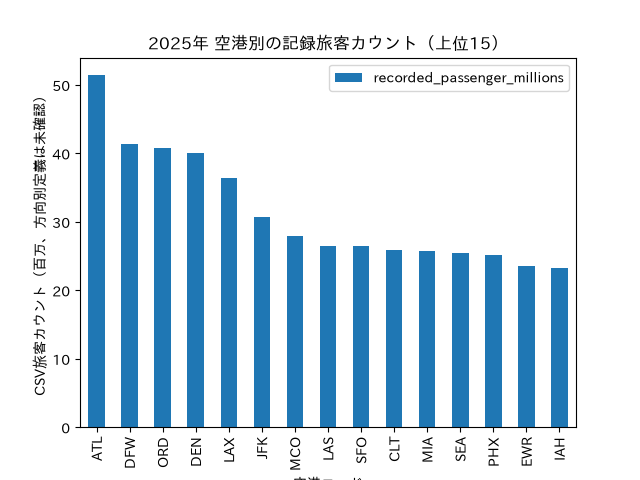

In [12]:
# 図1：上位15空港の記録旅客カウント
checkpoint()
execution_start()
try:
    airport_chart = airports.nlargest(15,'passengers_2025').sort_values('passengers_2025',ascending=False).assign(recorded_passenger_millions=lambda d:d.passengers_2025/1e6)
    with warnings.catch_warnings(record=True) as font_warnings:
        warnings.simplefilter('always')
        airport_png = visualization.render_chart(airport_chart, kind='bar', x='iata', y='recorded_passenger_millions', title='2025年 空港別の記録旅客カウント（上位15）', xlabel='空港コード', ylabel='CSV旅客カウント（百万、方向別定義は未確認）')
    glyph_messages = [str(w.message) for w in font_warnings if 'Glyph' in str(w.message)]
    print('MISSING_GLYPH_WARNINGS', glyph_messages)
    if glyph_messages:
        raise ValueError('日本語グリフの欠落を検出')
    show_chart_bytes(airport_png, '上位15空港')
finally:
    execution_end()


VISUAL_PIXEL_CHECK {"title": "都市定義比較", "png_bytes": 95707, "width": 1412, "height": 651, "ink_fraction": 0.31982393615401017}


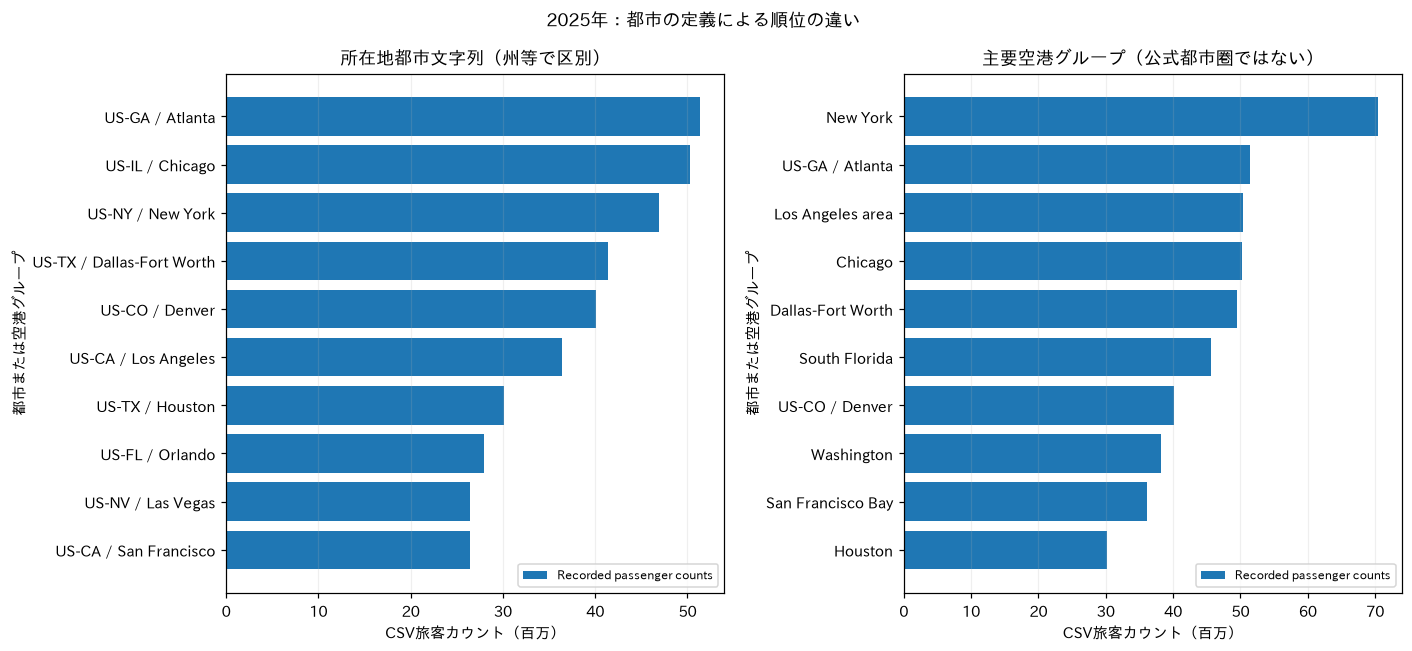

In [13]:
# 図2：都市文字列と主要空港グループの比較
checkpoint()
execution_start()
try:
    fig, axes = plt.subplots(1,2,figsize=(13,6))
    for ax, frame, key, title in [(axes[0],city_final,'city_key','所在地都市文字列（州等で区別）'),(axes[1],metro_final,'metro_key','主要空港グループ（公式都市圏ではない）')]:
        subset = frame.head(10).iloc[::-1]
        labels = subset[key].str.replace(' major-airport group','',regex=False)
        ax.barh(labels, subset.passengers/1e6, label='Recorded passenger counts')
        ax.set_title(title)
        ax.set_xlabel('CSV旅客カウント（百万）')
        ax.set_ylabel('都市または空港グループ')
        ax.legend(fontsize=8, loc='lower right')
        ax.grid(axis='x', alpha=0.2)
    fig.suptitle('2025年：都市の定義による順位の違い')
    fig.tight_layout()
    show_figure(fig, '都市定義比較')
finally:
    execution_end()


VISUAL_PIXEL_CHECK {"title": "経緯度バブル図", "png_bytes": 247624, "width": 1633, "height": 984, "ink_fraction": 0.07977797858199036}
MAP excluded unmatched airports: 22 recorded passengers: 50177


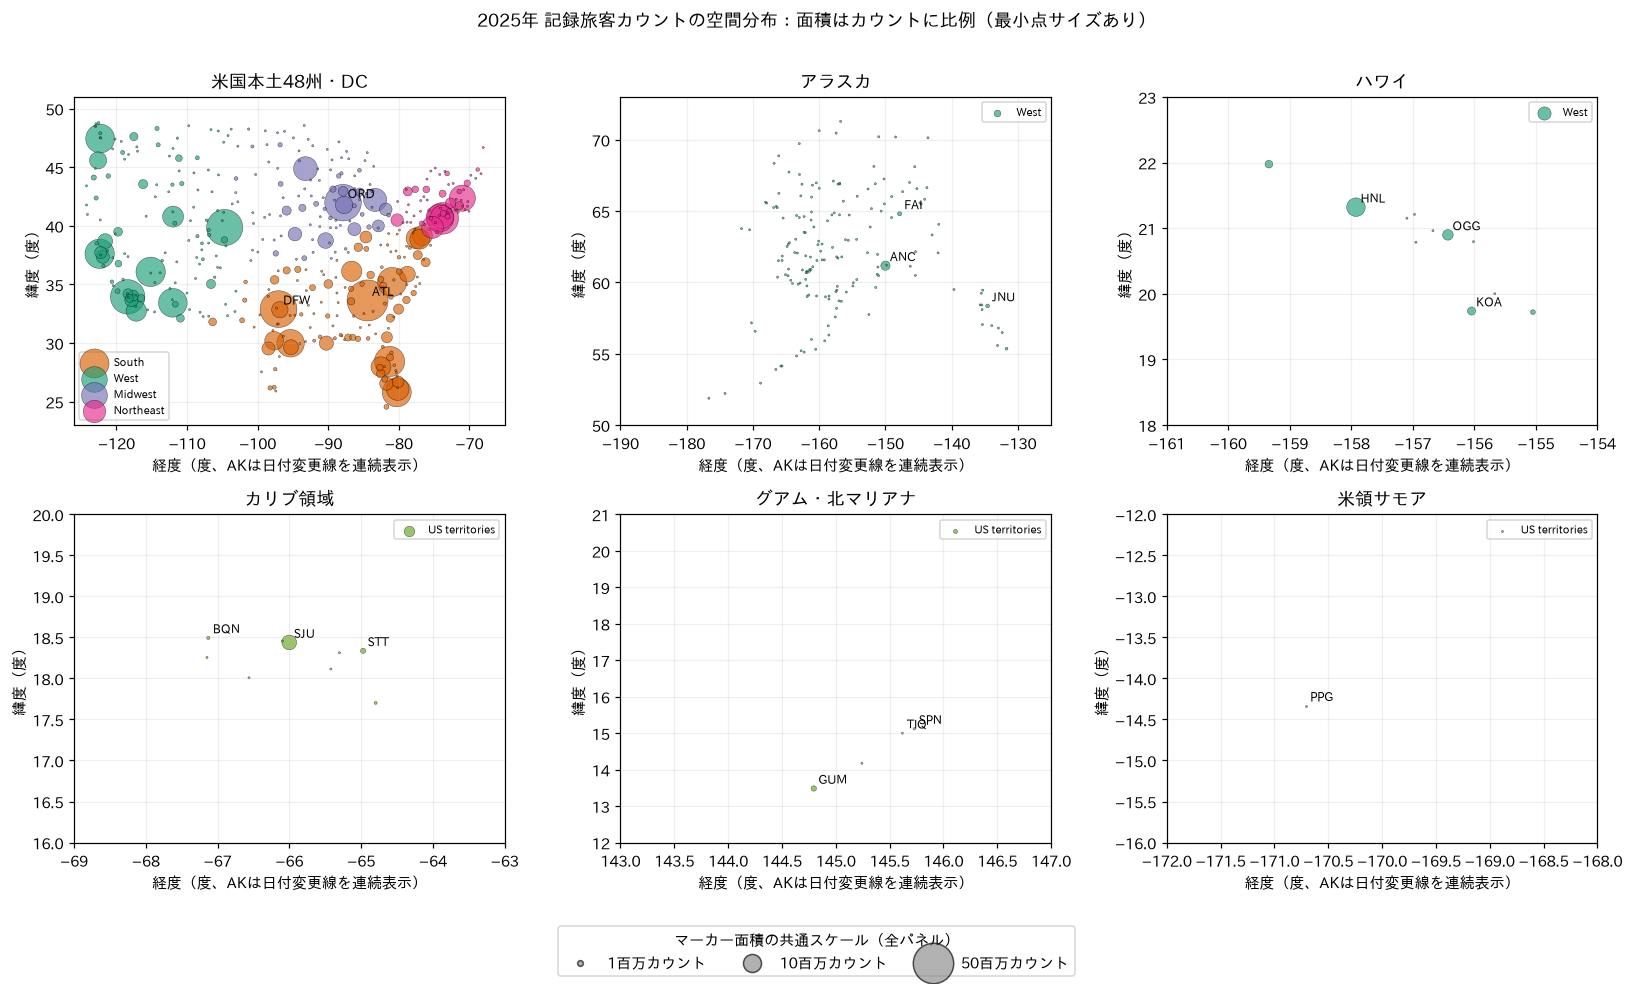

In [14]:
# 図3：経緯度バブル図（行政境界図ではない）
checkpoint()
execution_start()
try:
    fig, axes = plt.subplots(2,3,figsize=(15,9))
    region_colors = {'South':'#d95f02','West':'#1b9e77','Midwest':'#7570b3','Northeast':'#e7298a','US territories':'#66a61e','Unknown':'#666666'}
    map_frames = [
        ('米国本土48州・DC', improved.loc[improved.latitude.between(24,50) & improved.longitude.between(-125,-66) & improved.region.ne('US territories')], (-126,-65),(23,51)),
        ('アラスカ', improved.loc[improved.iso_region.eq('US-AK')], (-190,-125),(50,73)),
        ('ハワイ', improved.loc[improved.iso_region.eq('US-HI')], (-161,-154),(18,23)),
        ('カリブ領域', improved.loc[improved.country.isin(['Puerto Rico','Virgin Islands'])], (-69,-63),(16,20)),
        ('グアム・北マリアナ', improved.loc[improved.country.isin(['Guam','Northern Mariana Islands'])], (143,147),(12,21)),
        ('米領サモア', improved.loc[improved.country.eq('American Samoa')], (-172,-168),(-16,-12)),
    ]
    for ax,(title,frame,xlimits,ylimits) in zip(axes.flat,map_frames):
        for region,color in region_colors.items():
            points=frame.loc[frame.region.eq(region) & frame.latitude.notna()]
            if len(points):
                lon=points.longitude.where(points.longitude.le(0),points.longitude-360) if title=='アラスカ' else points.longitude
                ax.scatter(lon,points.latitude,s=np.maximum(points.passengers_2025/1e6*14,2),c=color,alpha=0.65,edgecolors='black',linewidths=0.3,label=region)
        for row in frame.nlargest(3,'passengers_2025').itertuples():
            lon=row.longitude-360 if title=='アラスカ' and row.longitude>0 else row.longitude
            ax.annotate(row.iata,(lon,row.latitude),fontsize=8,xytext=(3,3),textcoords='offset points')
        ax.set_title(title)
        ax.set_xlabel('経度（度、AKは日付変更線を連続表示）')
        ax.set_ylabel('緯度（度）')
        ax.set_xlim(*xlimits); ax.set_ylim(*ylimits)
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7,loc='best')
    fig.suptitle('2025年 記録旅客カウントの空間分布：面積はカウントに比例（最小点サイズあり）')
    size_handles = [Line2D([], [], marker='o', linestyle='', markersize=np.sqrt(14*m), markerfacecolor='#888888', markeredgecolor='black', alpha=0.65, label=f'{m}百万カウント') for m in [1,10,50]]
    fig.legend(handles=size_handles, loc='lower center', ncol=3, title='マーカー面積の共通スケール（全パネル）')
    fig.tight_layout(rect=[0,0.075,1,0.97])
    show_figure(fig,'経緯度バブル図')
    print('MAP excluded unmatched airports:', int(improved.latitude.isna().sum()), 'recorded passengers:', int(improved.loc[improved.latitude.isna(),'passengers_2025'].sum()))
finally:
    execution_end()


VISUAL_PIXEL_CHECK {"title": "地域偏り・集中度", "png_bytes": 77503, "width": 1417, "height": 539, "ink_fraction": 0.10552357210286437}


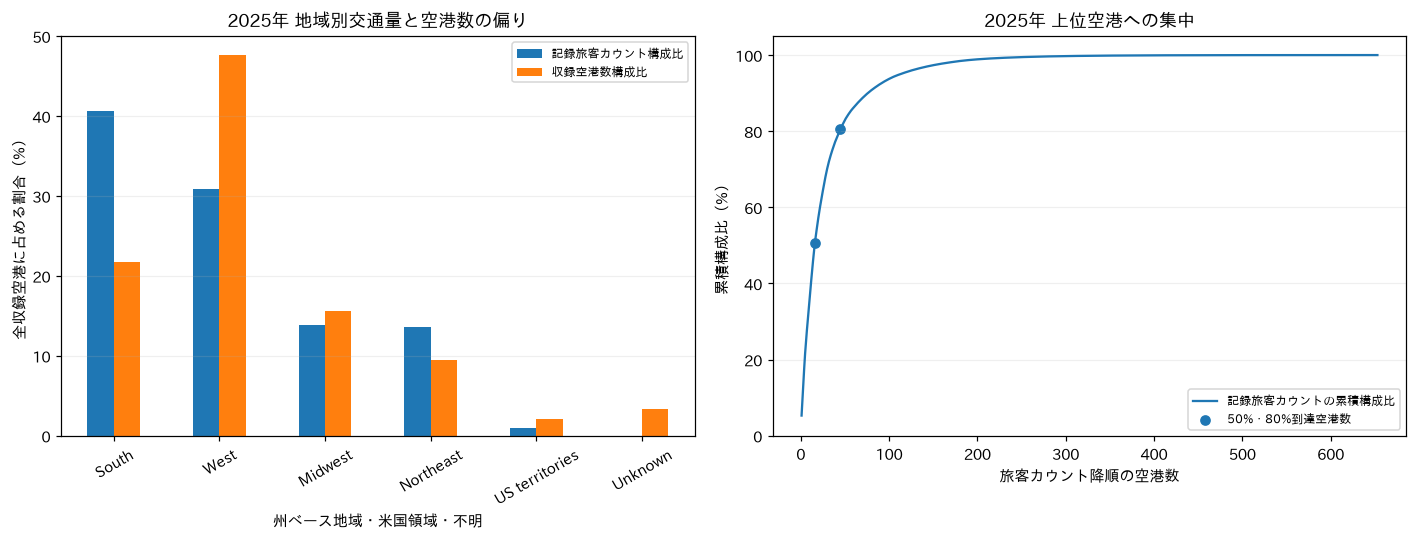

In [15]:
# 図4：地域偏りと空港集中度
checkpoint()
execution_start()
try:
    fig,axes=plt.subplots(1,2,figsize=(13,5))
    region_table.set_index('region')[['passenger_share_pct','airport_share_pct']].rename(columns={'passenger_share_pct':'記録旅客カウント構成比','airport_share_pct':'収録空港数構成比'}).plot.bar(ax=axes[0])
    axes[0].set_title('2025年 地域別交通量と空港数の偏り')
    axes[0].set_xlabel('州ベース地域・米国領域・不明')
    axes[0].set_ylabel('全収録空港に占める割合（%）')
    axes[0].tick_params(axis='x', rotation=30)
    axes[0].legend(fontsize=8)
    axes[1].plot(ranked['rank'],ranked.cumulative_share_pct,label='記録旅客カウントの累積構成比')
    axes[1].scatter([16,45],[ranked.iloc[15].cumulative_share_pct,ranked.iloc[44].cumulative_share_pct],label='50%・80%到達空港数')
    axes[1].set_title('2025年 上位空港への集中')
    axes[1].set_xlabel('旅客カウント降順の空港数')
    axes[1].set_ylabel('累積構成比（%）')
    axes[1].set_ylim(0,105)
    axes[1].legend(fontsize=8,loc='lower right')
    for ax in axes:
        ax.grid(axis='y',alpha=0.2)
    fig.tight_layout()
    show_figure(fig,'地域偏り・集中度')
finally:
    execution_end()


In [16]:
# Jupytermind改善候補の再現ログ（分析結果とは別）
probe_inferred_manifest = data_definition.build_manifest(source={}, dataset_scope={}, variables={'traffic': {'unit': data_definition.FieldValue('passenger count', 'inferred', 'column name')}})
probe_inferred_unresolved = probe_inferred_manifest.unresolved_fields()
print('PROBE_1 inferred_only unresolved_fields:', probe_inferred_unresolved, 'inferred fields exist:', True)
probe_visual_nb = nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('chart', execution_count=1, outputs=[visualization.build_image_output(airport_png)])])
probe_visual_findings = notebook_audit.audit_visual_outputs(probe_visual_nb, (0,))
print('PROBE_2 image with NO chart metadata visual_findings:', [asdict(f) for f in probe_visual_findings])
try:
    visualization.render_chart(airport_chart, kind='barh', x='iata', y='recorded_passenger_millions')
except ValueError as exc:
    print('PROBE_3 horizontal bar support:', str(exc))
print('本番図表には実際のタイトル・軸・凡例・欠落グリフ情報を手動metadataとして付加し、PNG画素率も実測して監査を補強した。')

probe_stream_nb = nbformat.v4.new_notebook(cells=[nbformat.v4.new_code_cell('print(403903)', execution_count=1, outputs=[nbformat.v4.new_output('stream', name='stdout', text='403903\n')])])
print('PROBE_4 stream evidence supported:', insight_engine._find_evidence_cell(probe_stream_nb, 1, '403903') is not None)


PROBE_1 inferred_only unresolved_fields: [] inferred fields exist: True
PROBE_2 image with NO chart metadata visual_findings: []
PROBE_3 horizontal bar support: Unsupported chart kind: 'barh'
本番図表には実際のタイトル・軸・凡例・欠落グリフ情報を手動metadataとして付加し、PNG画素率も実測して監査を補強した。
PROBE_4 stream evidence supported: False


## 使用したJupytermindモジュール
直接import・呼び出したもののみを記載する（間接利用は含めない）。

| モジュール | 直接使用した関数・クラス | 使用目的 |
|---|---|---|
| ai_data_scientist.project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | slug検証、固定保存先、データ配置、ノートブック直列書込み |
| ai_data_scientist.language_router | detect_language | 日本語判定 |
| ai_data_scientist.lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, get_run_status, mark_completed, mark_failed | run追跡・キャンセル確認・実行/書込み/終端状態 |
| ai_data_scientist.ingestion | SourceSpec, ingest | 取得CSVの読込みと行数上限 |
| ai_data_scientist.cleaning | clean_dataset | 完全一致重複の検査・除去（除去0） |
| ai_data_scientist.eda | explore | 型・分布・欠損・カテゴリ確認 |
| ai_data_scientist.data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 項目定義・単位・出典・不確実性 |
| ai_data_scientist.analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 非因果範囲・結論に重要な仮定と警告 |
| ai_data_scientist.data_quality | detect_anomalies | 非負・一意・欠損・緯経度範囲等の意味的異常検査 |
| ai_data_scientist.dataset_validation | compare_datasets | 既に取得した地理参照のキー重複・座標一致検査（overlapping） |
| ai_data_scientist.sensitivity | SensitivityPlan, run_sensitivity | 単位倍率・対象空港・旅客/便数・地域/都市定義の感度 |
| ai_data_scientist.visualization | render_chart, build_image_output | 対応形式の棒グラフ、日本語フォント、PNG MIME出力 |
| ai_data_scientist.insight_engine | extract_cited_value, record_insight, _find_evidence_cell（再現確認のみ） | 実行済み出力から値を抽出し根拠付き結論を保存 |
| ai_data_scientist.notebook_audit | audit_notebook, audit_visual_outputs | nbformat・実行/エラー/根拠/visual_audit=True監査と再現プローブ |

使用しない機能：mcp_gateway.run_and_recordはホスト側同期MCPClientを要求するが、この作業は既存Jupyter MCPのexecute_cellで外側から実行するためカーネル内にそのclientは無い。偽clientや同一カーネルへの再帰実行を使わず、実行はネイティブJupyter MCP、ソース書込みはenqueue_writeに分離した。stats_analysis.correlationは本設問に不要、anomaly_detectionのz-scoreは大ハブを誤って異常扱いし得るため意味的検査を優先。validate_anomaliesと独立交通データ検証は独立参照なし、ML・クラスタリング・因果推論・月次季節性は対象外。地理の厳密一致は浮動小数の丸め差も不一致と判定するため、0.05度以内の独自許容検査を併用した。

## Jupytermind改善候補
本作業ではライブラリ本体を修正せず、再現と影響・回避策を記録する。関係セルはソース先頭の識別コメント（再実行後の実行番号は根拠/最終監査で更新）で特定する。

| 分類 | 再現条件 | 期待する挙動 | 実際の挙動 | 影響 | 回避策 | 関係セル・ログ |
|---|---|---|---|---|---|---|
| API機能不足・ワークフロー支援 | inferredのみのFieldValueでunresolved_fieldsを呼ぶ | unknownとinferredをまとめて列挙できる選択肢 | unknownのみ列挙（実装docstringと一致） | inferredの注意点を呼出側が落とす可能性 | inferredを明示抽出し未知項目と別記 | 反復1、改善候補PROBE_1（空リスト） |
| 視覚監査の偽陰性 | image/pngはあるがmetadata.chartが無い | タイトル・軸・凡例・グリフ情報の欠落を指摘 | visual_findingsが空になる | metadataを全く付けない図ほど監査を通る | 本番4図へ実測に対応するmetadataを付加、画素率実測・目視確認を併用 | 改善候補PROBE_2、図1–4、最終visual audit |
| 可視化の機能不足 | render_chart(kind='barh') | 長い都市ラベルに適した横棒を指定可能 | Unsupported chart kind: 'barh' | 横棒・複合図・サイズ付き地理図はrender_chartだけで作れない | 空港図は対応barへ変更、都市・地理・複合図は同じJupyterセル内のmatplotlibで作成 | 初回図1のValueError、改善候補PROBE_3、修正後図1 |

| 根拠照合の不具合 | 実行済みcodeセルの標準printがstream.textに数値を出す | stream出力の実値も根拠として照合 | record_insightがEvidenceMissingError。照合対象はoutput.dataのみ | 標準print中心の分析では妥当な根拠を拒否する。Notebook auditも同様の判定制約 | 同じ計算値をdisplayのtext/plain MIMEへ明示表示してから記録 | 根拠記録初回（ORD 403903のEvidenceMissingError）、PROBE_4 False、修正後反復1–3 |

問題の切分け：Kaggle SDKのdataset_listへの非対応page_size指定による初回TypeError、およびcandidate_relationshipに自由文を与えたValueErrorは分析コードの呼出側誤りであり修正済み。Kaggleデータの年次旅客列全欠損、旅客定義と集計値の不整合、古い空港コードはデータ品質・掲載メタデータの問題でJupytermindの不具合ではない。MCP初期保存ディレクトリ・filesystem許可範囲の不一致はツール設定問題。ベンチマークランナーは実行せず、その障害の証拠もない。


### 実行環境との統合ログ（原因切分け中）
Jupyter MCPのexecute_cellで自ノートブックへenqueue_writeを行うセルは、処理が成功してもMCP結果がoutputs=[]、count=0となり、当該セルのexecution_countが未設定のままになった。根拠Markdownの追加自体は保存された。ライブラリ単体かライブNotebook同期の問題かは未確定で、Jupytermindの確定不具合とは扱わない。回避策は、当該2セルのみ実際のstdoutをStringIOで捕捉し、処理成功後に実際のカーネルexecution_countと出力をenqueue_writeで保存する。未実行・失敗セルを実行済みと偽装せず、監査はその後に行う。関係セル：根拠付き結論、最終監査、persist_cell_execution。


In [18]:
# 根拠付き結論と成果物manifestの記録（再実行時に更新）
self_record_log = io.StringIO()
with contextlib.redirect_stdout(self_record_log):
    checkpoint()
    execution_start()
    try:
        write_nb(lambda nb: setattr(nb, 'cells', [cell for cell in nb.cells if not cell.metadata.get('analysis_insight')]))
        persisted = nbformat.read(handle.notebook_path, as_version=4)
        def evidence_for(marker, pattern):
            cell = next(c for c in persisted.cells if c.cell_type == 'code' and c.source.startswith(marker))
            output_text = '\n'.join(str(o.get('text', o.get('data', {}).get('text/plain',''))) for o in cell.outputs)
            value = insight_engine.extract_cited_value({'output': output_text}, pattern)
            return cell.execution_count, value
        specifications = [
            ('# 反復2：IATA参照との比較', r'ATL_RECORDED_PASSENGERS\s+(\d+)', '空港別の記録旅客カウント首位はATLで、CSV値は{value}。掲載者の乗降合計という説明には不整合が残るため、独立確認済み年間乗降人数とは解釈しない。'),
            ('# 反復2：IATA参照との比較', r'ORD_RECORDED_FLIGHTS\s+(\d+)', '便数列の首位はORDで、CSV値は{value}。旅客首位ATLとは異なり、交通指標によって順位が変わる。'),
            ('# 反復2：IATA参照との比較', r'NYC_GROUP_PASSENGERS\s+(\d+)', '所在地都市文字列ではAtlantaが首位だが、JFK・LGA・EWRをまとめるとNew York主要空港グループが{value}で首位になる。公式都市圏境界による集計ではなく、都市定義の感度比較である。'),
            ('# 反復3：地域分類と感度分析', r'AIRPORT_TOP10_SHARE_PCT\s+([0-9.]+)', '上位10空港は収録653空港の記録旅客合計の{value}%を占める。上位16で50%、上位45で80%に到達する。全国旅客総量に占めるシェアではない。'),
            ('# 反復3：地域分類と感度分析', r'SOUTH_SHARE_PCT\s+([0-9.]+)', '州ベースの南部は収録旅客カウントの{value}%を占め地域首位。空港数シェアは約21.75%で、交通量は空港数より南部へ偏る。ATL除外・10万未満除外でも地域首位を維持し、感度stable=True・最大相対偏差約8.14%。人口や面積あたりの需要・因果効果を示す結果ではない。'),
            ('# 反復1：ファイル整合性', r'"history_missing_passengers": (\d+)', '空港別年次旅客CSVでは{value}行すべて旅客値が欠損。空港・都市ごとの成長率は分析不可。全国系列は利用可能だが空港別合計と一致せず、2026年は部分年なので主比較から除外した。'),
            ('# 反復3：地域分類と感度分析', r'FLIGHT_TOP10_SHARE_PCT\s+([0-9.]+)', '便数の上位10空港シェアは{value}%で旅客集中度とは異なる。指標変更込みの感度はstable=False（最大相対偏差約12.53%）、旅客/便数別の小空港除外感度は別に記録する。東西境界感度stable=False（約27.53%）、都市定義感度stable=False（約37.02%）につき、境界や都市定義に依存しない精密なシェア・首位とは言わない。'),
        ]
        for marker, pattern, text in specifications:
            count,value=evidence_for(marker,pattern)
            lifecycle.mark_write_start(run_id)
            try:
                insight_engine.record_insight(handle,text.format(value=value),count,value,'descriptive',language=language)
            finally:
                lifecycle.mark_write_end(run_id)
            def tag_last(nb):
                nb.cells[-1].metadata['analysis_insight']=True
            write_nb(tag_last)
            print('EVIDENCE_RECORDED', marker, count, value)
        def move_insights_before_audit(nb):
            insights=[cell for cell in nb.cells if cell.metadata.get('analysis_insight')]
            other=[cell for cell in nb.cells if not cell.metadata.get('analysis_insight')]
            audit_index=next(i for i,c in enumerate(other) if c.cell_type=='code' and c.source.startswith('# 最終監査'))
            nb.cells=other[:audit_index]+insights+other[audit_index:]
        write_nb(move_insights_before_audit)
        definition_manifest.variables['geographic_join'] = {
            'method': data_definition.FieldValue('IATA参照優先。ICAOをident/gps_codeへ照合し、座標一致時のみUS local_code補助を利用', 'verified','iteration2 code'),
            'reference_date': data_definition.FieldValue('両地理CSVの基準日・2025年との歴史的一致は未確認', 'unknown','metadata'),
            'city_definition': data_definition.FieldValue('州等+city文字列。主要空港グループは定義表を別途明示', 'verified','metro_groups'),
        }
        definition_manifest.source['second_geography'] = data_definition.FieldValue('syedasimalishah/airports; OurAirports ancestry overlaps', 'verified', provenance[-1]['url'])
        artifacts={'provenance':provenance,'data_definition_manifest':asdict(definition_manifest),'analysis_assumption_manifest':asdict(final_assumption_manifest),'sensitivity':{'unit':asdict(unit_sensitivity),'concentration':asdict(concentration_sensitivity),'within_measure':{k:asdict(v) for k,v in within_measure_sensitivity.items()},'geographic':asdict(geographic_sensitivity),'east_west':asdict(east_west_sensitivity),'city_definition':asdict(city_definition_sensitivity)}}
        (data_dir/'analysis-manifests.json').write_text(json.dumps(artifacts,ensure_ascii=False,indent=2,default=str),encoding='utf-8')
        print('FINAL_PROVENANCE', json.dumps(provenance,ensure_ascii=False))
        print('FINAL_WARNINGS', [asdict(f) for f in final_assumption_findings])
        print('FINAL_WITHIN_MEASURE_STABILITY', {k:{'stable':v.stable,'max_relative_deviation':v.max_relative_deviation} for k,v in within_measure_sensitivity.items()})
        print('FINAL_VISUAL_LOGS', visual_logs)
    finally:
        execution_end()
persist_cell_execution('# 根拠付き結論と成果物manifestの記録', self_record_log.getvalue())
print(self_record_log.getvalue())


EVIDENCE_RECORDED # 反復2：IATA参照との比較 9 51408843
EVIDENCE_RECORDED # 反復2：IATA参照との比較 9 403903
EVIDENCE_RECORDED # 反復2：IATA参照との比較 9 70438812
EVIDENCE_RECORDED # 反復3：地域分類と感度分析 10 35.719116
EVIDENCE_RECORDED # 反復3：地域分類と感度分析 10 40.679494
EVIDENCE_RECORDED # 反復1：ファイル整合性 7 19332
EVIDENCE_RECORDED # 反復3：地域分類と感度分析 10 31.243949
FINAL_PROVENANCE [{"owner_dataset_slug": "himaxym/us-air-traffic-t100", "filename": "airport_totals_2025.csv", "retrieved_at_utc": "2026-10-01T20:58:05.361002+00:00", "sha256": "4299a70801d71656428ce0f5f24b6581bd27eb9eb461e25d25055e0560cbf58d", "bytes": 12075, "url": "https://www.kaggle.com/datasets/himaxym/us-air-traffic-t100", "fallback": false}, {"owner_dataset_slug": "himaxym/us-air-traffic-t100", "filename": "airport_passengers_by_year.csv", "retrieved_at_utc": "2026-10-01T20:58:07.483404+00:00", "sha256": "08c6eb93464437b35f180aded0d2020604794ffd6fdde2212deb6a636d9cafce", "bytes": 193341, "url": "https://www.kaggle.com/datasets/himaxym/us-air-traffic-t100", "fallback":

空港別の記録旅客カウント首位はATLで、CSV値は51408843。掲載者の乗降合計という説明には不整合が残るため、独立確認済み年間乗降人数とは解釈しない。

```evidence
{"execution_count":9,"cited_value":"51408843","claim_type":"descriptive"}
```

便数列の首位はORDで、CSV値は403903。旅客首位ATLとは異なり、交通指標によって順位が変わる。

```evidence
{"execution_count":9,"cited_value":"403903","claim_type":"descriptive"}
```

所在地都市文字列ではAtlantaが首位だが、JFK・LGA・EWRをまとめるとNew York主要空港グループが70438812で首位になる。公式都市圏境界による集計ではなく、都市定義の感度比較である。

```evidence
{"execution_count":9,"cited_value":"70438812","claim_type":"descriptive"}
```

上位10空港は収録653空港の記録旅客合計の35.719116%を占める。上位16で50%、上位45で80%に到達する。全国旅客総量に占めるシェアではない。

```evidence
{"execution_count":10,"cited_value":"35.719116","claim_type":"descriptive"}
```

州ベースの南部は収録旅客カウントの40.679494%を占め地域首位。空港数シェアは約21.75%で、交通量は空港数より南部へ偏る。ATL除外・10万未満除外でも地域首位を維持し、感度stable=True・最大相対偏差約8.14%。人口や面積あたりの需要・因果効果を示す結果ではない。

```evidence
{"execution_count":10,"cited_value":"40.679494","claim_type":"descriptive"}
```

空港別年次旅客CSVでは19332行すべて旅客値が欠損。空港・都市ごとの成長率は分析不可。全国系列は利用可能だが空港別合計と一致せず、2026年は部分年なので主比較から除外した。

```evidence
{"execution_count":7,"cited_value":"19332","claim_type":"descriptive"}
```

便数の上位10空港シェアは31.243949%で旅客集中度とは異なる。指標変更込みの感度はstable=False（最大相対偏差約12.53%）、旅客/便数別の小空港除外感度は別に記録する。東西境界感度stable=False（約27.53%）、都市定義感度stable=False（約37.02%）につき、境界や都市定義に依存しない精密なシェア・首位とは言わない。

```evidence
{"execution_count":10,"cited_value":"31.243949","claim_type":"descriptive"}
```

## 保存後の確定監査

全コードセル18/18実行済み、エラー・未実行セルなし。根拠付き結論7件、図4件、visual_findingsなし。保存後audit_notebook(visual_audit=True)のok: True。run_id v020-exp-27 の状態: completed、active executions / pending writes / locks = 0 / 0 / 0。

```json
{
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-27-airport-traffic/notebooks/kaggle-v020-kaggle-exp-27-airport-traffic.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 18,
  "executed_code_cell_count": 18,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    17,
    18,
    19,
    20
  ],
  "insight_cell_count": 7,
  "findings": [],
  "visual_findings": []
}
```

In [19]:
# 最終監査：visual_audit=True・ライフサイクル終端状態
self_record_log = io.StringIO()
with contextlib.redirect_stdout(self_record_log):
    checkpoint()
    try:
        audit_report = notebook_audit.audit_notebook(handle.notebook_path, visual_audit=True)
        print('NOTEBOOK_AUDIT', json.dumps(asdict(audit_report),ensure_ascii=False,default=str))
        print('AUDIT_OK', audit_report.ok)
        if not audit_report.ok:
            lifecycle.mark_failed(run_id)
            write_nb(lambda nb: nb.metadata.update({'lifecycle':asdict(lifecycle.get_run_status(run_id)), 'notebook_audit':asdict(audit_report)}))
            raise RuntimeError('最終ノートブック監査に失敗。未解決findingを確認してください。')
        write_nb(lambda nb: nb.metadata.update({'notebook_audit':asdict(audit_report),'visual_audit':True,'analysis_run_id':run_id,'reexecuted_top_to_bottom':True,'data_provenance':provenance}))
        lifecycle.mark_completed(run_id)
        phase_event('completed')
        final_status = asdict(lifecycle.get_run_status(run_id))
        write_nb(lambda nb: nb.metadata.update({'lifecycle':final_status,'lifecycle_events':lifecycle_events}))
        print('LIFECYCLE_FINAL', asdict(lifecycle.get_run_status(run_id)))
    except Exception:
        lifecycle.mark_failed(run_id)
        print('LIFECYCLE_FAILED', asdict(lifecycle.get_run_status(run_id)))
        raise
persist_cell_execution('# 最終監査', self_record_log.getvalue())
print(self_record_log.getvalue())


NOTEBOOK_AUDIT {"path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-27-airport-traffic/notebooks/kaggle-v020-kaggle-exp-27-airport-traffic.ipynb", "nbformat_valid": true, "code_cell_count": 18, "executed_code_cell_count": 17, "unexecuted_cell_indices": [], "error_cell_indices": [], "chart_cell_indices": [17, 18, 19, 20], "insight_cell_count": 7, "findings": [{"severity": "warning", "message": "Trailing cell invokes audit_notebook and has not finished executing yet; excluded from unexecuted-cell findings.", "cell_index": 31}], "visual_findings": []}
AUDIT_OK True
LIFECYCLE_FINAL {'run_id': 'v020-exp-27', 'state': 'completed', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-27-airport-traffic/notebooks/kaggle-v020-kaggle-exp-27-airport-traffic.ipynb', 'reason': None}
